# FreeVIZ and SPCA comparison

In this notebook, we compare resulting vizualizations of FreeViz and SPCA for classification on four datasets.

In [4]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import torch
import matplotlib.pyplot as plt
import numpy as np

import importlib
import utils
importlib.reload(utils)

from models import Freeviz
from models.spca_classification import SPCA_Classification
from utils import load_zoo_data, load_car_data, load_mushroom_data, load_glass_data, load_breast_cancer_data, scale_features, plot_projection, select_lambda

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# The ZOO dataset

#### Data preparation

In [6]:
E_raw, C, names, feature_names, class_names = load_zoo_data(device)
E = scale_features(E_raw)

In [7]:
# Select optimal lambda for SPCA on Zoo data
E_zoo_f64 = E.to(torch.float64)
best_lam_zoo = select_lambda(SPCA_Classification, E_zoo_f64, C,
                             num_classes=len(class_names), steps=500)


Step 0: loss = 1.8613, classifier loss = 1.8541
Step 10: loss = 1.1977, classifier loss = 1.1879
Step 20: loss = 0.9333, classifier loss = 0.9227
Step 30: loss = 0.8018, classifier loss = 0.7910
Step 40: loss = 0.6912, classifier loss = 0.6800
Step 50: loss = 0.5943, classifier loss = 0.5822
Step 60: loss = 0.5191, classifier loss = 0.5067
Step 70: loss = 0.4587, classifier loss = 0.4460
Step 80: loss = 0.4083, classifier loss = 0.3954
Step 90: loss = 0.3654, classifier loss = 0.3523
Step 100: loss = 0.3287, classifier loss = 0.3153
Step 110: loss = 0.2971, classifier loss = 0.2835
Step 120: loss = 0.2698, classifier loss = 0.2561
Step 130: loss = 0.2462, classifier loss = 0.2323
Step 140: loss = 0.2257, classifier loss = 0.2117
Step 150: loss = 0.2078, classifier loss = 0.1936
Step 160: loss = 0.1921, classifier loss = 0.1778
Step 170: loss = 0.1781, classifier loss = 0.1638
Step 180: loss = 0.1656, classifier loss = 0.1513
Step 190: loss = 0.1542, classifier loss = 0.1398
Step 200: l

#### Train FreeVIZ

In [8]:
freeviz = Freeviz(E.shape[1]).to(device)
freeviz.train(E, C)

P = freeviz(E)
A = freeviz.A
P_np = P.detach().cpu().numpy()
C_np = C.detach().cpu().numpy()
A_np = A.detach().cpu().numpy()

step: 1 loss: 18686.888671875
step: 2 loss: 18908.298828125
step: 3 loss: 20747.65625
step: 4 loss: 19673.408203125
step: 5 loss: 12314.7578125
step: 6 loss: 11629.3037109375
step: 7 loss: 12073.1474609375
step: 8 loss: 12357.669921875
step: 9 loss: 12604.470703125
step: 10 loss: 12704.3095703125
step: 11 loss: 12857.6171875


#### Train SPCA Classification

In [9]:
model = SPCA_Classification(input_dim=E.shape[1], latent_dim=2, num_classes=len(class_names), lr=0.05).to(device)
E_centered = E - E.mean(dim=0)
lam = best_lam_zoo
steps = 1000
model.train(E_centered, C, lam=lam, steps=steps, classifier_epochs=50)

L = model.L.detach().clone()
L = L - L.mean(dim=0, keepdim=True)
loading_norms = torch.norm(L, dim=1)
L = L / loading_norms.max()

Z = E_centered @ L
z_max = torch.abs(Z).max()
Z = Z / z_max

Z_np = Z.cpu().numpy()
C_np_spca = C.cpu().numpy()
L_np = L.cpu().numpy()

Step 0: loss = 2.7072, classifier loss = 1.8537
Step 10: loss = 2.0431, classifier loss = 1.1845
Step 20: loss = 1.7740, classifier loss = 0.9122
Step 30: loss = 1.6475, classifier loss = 0.7844
Step 40: loss = 1.5710, classifier loss = 0.7065
Step 50: loss = 1.5159, classifier loss = 0.6502
Step 60: loss = 1.4723, classifier loss = 0.6051
Step 70: loss = 1.4359, classifier loss = 0.5671
Step 80: loss = 1.4046, classifier loss = 0.5342
Step 90: loss = 1.3773, classifier loss = 0.5048
Step 100: loss = 1.3525, classifier loss = 0.4768
Step 110: loss = 1.3274, classifier loss = 0.4443
Step 120: loss = 1.2976, classifier loss = 0.3989
Step 130: loss = 1.2663, classifier loss = 0.3511
Step 140: loss = 1.2393, classifier loss = 0.3135
Step 150: loss = 1.2167, classifier loss = 0.2843
Step 160: loss = 1.1976, classifier loss = 0.2610
Step 170: loss = 1.1813, classifier loss = 0.2418
Step 180: loss = 1.1671, classifier loss = 0.2255
Step 190: loss = 1.1545, classifier loss = 0.2115
Step 200: l

### Side-by-side comparison

/usr/lib/python3/dist-packages/matplotlib/transforms.py:627: RuntimeWarning: invalid value encountered in scalar subtract
  deltaw = (sw * width - width) / 2.0
/usr/lib/python3/dist-packages/matplotlib/transforms.py:628: RuntimeWarning: invalid value encountered in scalar subtract
  deltah = (sh * height - height) / 2.0
Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


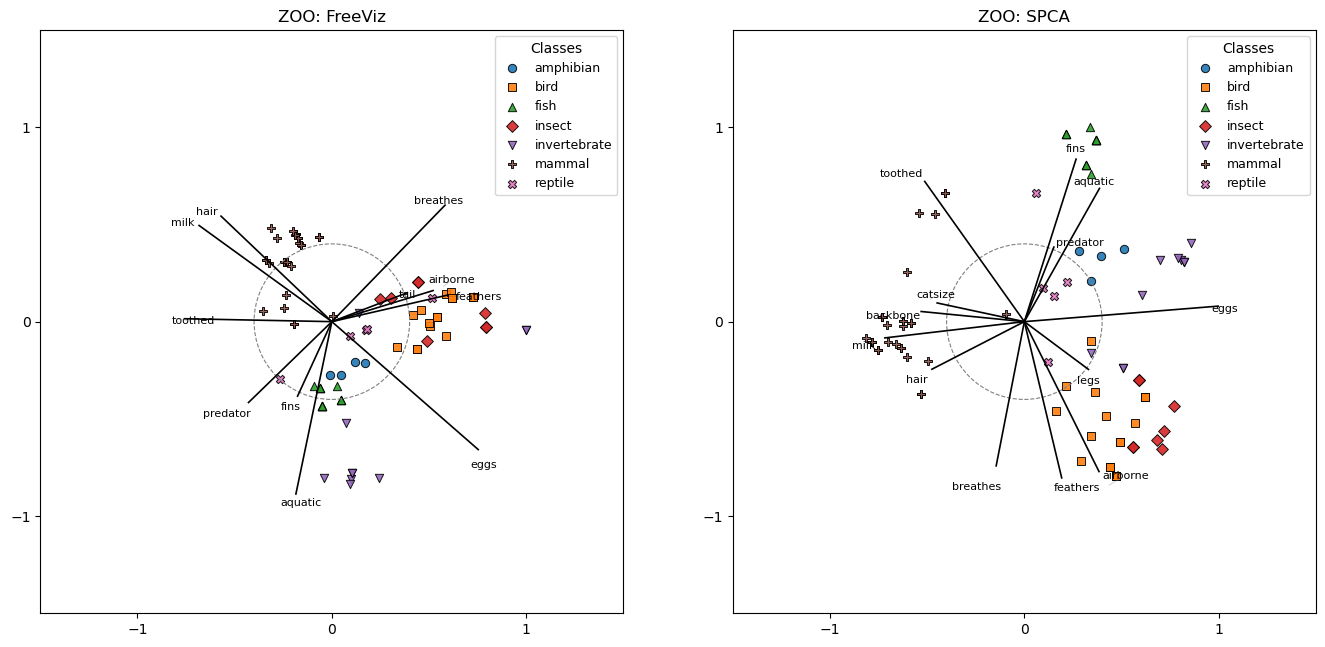

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))

plot_projection(
    P_np, A_np, feature_names, C_np, class_names,
    title='ZOO: FreeViz', ax=ax1, text_scale=1.08, normalize_points=True
)

plot_projection(
    Z_np, L_np, feature_names, C_np_spca, class_names,
    title='ZOO: SPCA', ax=ax2, text_scale=1.1
)

plt.tight_layout()
plt.show()

# The MUSHROOM dataset

#### Data preparation

In [11]:
E_mush, C_mush, names_mush, feature_names_mush, class_names_mush = load_mushroom_data(device)
E_mush = scale_features(E_mush)

In [12]:
# Select optimal lambda for SPCA on Mushroom data
E_mush_f64 = E_mush.to(torch.float64)
best_lam_mush = select_lambda(SPCA_Classification, E_mush_f64, C_mush,
                             num_classes=len(class_names_mush), steps=500)


Step 0: loss = 1.2523, classifier loss = 0.6334
Step 10: loss = 0.9732, classifier loss = 0.3457
Step 20: loss = 0.8782, classifier loss = 0.2403
Step 30: loss = 0.8312, classifier loss = 0.1849
Step 40: loss = 0.8024, classifier loss = 0.1499
Step 50: loss = 0.7826, classifier loss = 0.1257
Step 60: loss = 0.7682, classifier loss = 0.1082
Step 70: loss = 0.7575, classifier loss = 0.0951
Step 80: loss = 0.7562, classifier loss = 0.0933
Step 90: loss = 0.7550, classifier loss = 0.0919
Step 100: loss = 0.7538, classifier loss = 0.0905
Step 110: loss = 0.7527, classifier loss = 0.0892
Step 120: loss = 0.7515, classifier loss = 0.0879
Step 130: loss = 0.7505, classifier loss = 0.0867
Step 140: loss = 0.7494, classifier loss = 0.0854
Step 150: loss = 0.7483, classifier loss = 0.0842
Step 160: loss = 0.7473, classifier loss = 0.0830
Step 170: loss = 0.7463, classifier loss = 0.0819
Step 180: loss = 0.7453, classifier loss = 0.0807
Step 190: loss = 0.7443, classifier loss = 0.0796
Step 200: l

#### Train FreeVIZ

In [13]:
freeviz_mush = Freeviz(E_mush.shape[1]).to(device)
freeviz_mush.train(E_mush, C_mush)

P_mush = freeviz_mush(E_mush)
A_mush = freeviz_mush.A
P_mush_np = P_mush.detach().cpu().numpy()
C_mush_np = C_mush.detach().cpu().numpy()
A_mush_np = A_mush.detach().cpu().numpy()

step: 1 loss: 11156905.0
step: 2 loss: 2272079.75
step: 3 loss: 2261446.25
step: 4 loss: 2273533.5
step: 5 loss: 2274354.5
step: 6 loss: 2257592.5
step: 7 loss: 2247793.75
step: 8 loss: 2246795.5
step: 9 loss: 2227085.5
step: 10 loss: 2224087.5
step: 11 loss: 2188089.0


#### Train SPCA Classification

In [14]:
model_mush = SPCA_Classification(input_dim=E_mush.shape[1], latent_dim=2, num_classes=len(class_names_mush), lr=0.05).to(device)
E_mush_centered = E_mush - E_mush.mean(dim=0)
model_mush.train(E_mush_centered, C_mush, lam=best_lam_mush, steps=1000, classifier_epochs=50)

L_mush = model_mush.L.detach().clone()
L_mush = L_mush - L_mush.mean(dim=0, keepdim=True)
loading_norms_mush = torch.norm(L_mush, dim=1)
L_mush = L_mush / loading_norms_mush.max()

Z_mush = E_mush_centered @ L_mush
z_max_mush = torch.abs(Z_mush).max()
Z_mush = Z_mush / z_max_mush

Z_mush_np = Z_mush.cpu().numpy()
C_mush_np_spca = C_mush.cpu().numpy()
L_mush_np = L_mush.cpu().numpy()

Step 0: loss = 1.4128, classifier loss = 0.6434
Step 10: loss = 1.1294, classifier loss = 0.3526
Step 20: loss = 1.0373, classifier loss = 0.2502
Step 30: loss = 0.9940, classifier loss = 0.1978
Step 40: loss = 0.9680, classifier loss = 0.1644
Step 50: loss = 0.9504, classifier loss = 0.1409
Step 60: loss = 0.9374, classifier loss = 0.1236
Step 70: loss = 0.9318, classifier loss = 0.1155
Step 80: loss = 0.9306, classifier loss = 0.1141
Step 90: loss = 0.9295, classifier loss = 0.1123
Step 100: loss = 0.9284, classifier loss = 0.1109
Step 110: loss = 0.9273, classifier loss = 0.1094
Step 120: loss = 0.9262, classifier loss = 0.1080
Step 130: loss = 0.9252, classifier loss = 0.1066
Step 140: loss = 0.9242, classifier loss = 0.1052
Step 150: loss = 0.9232, classifier loss = 0.1039
Step 160: loss = 0.9223, classifier loss = 0.1026
Step 170: loss = 0.9214, classifier loss = 0.1014
Step 180: loss = 0.9205, classifier loss = 0.1001
Step 190: loss = 0.9196, classifier loss = 0.0989
Step 200: l

### Side-by-side comparison

/usr/lib/python3/dist-packages/matplotlib/transforms.py:627: RuntimeWarning: invalid value encountered in scalar subtract
  deltaw = (sw * width - width) / 2.0
/usr/lib/python3/dist-packages/matplotlib/transforms.py:628: RuntimeWarning: invalid value encountered in scalar subtract
  deltah = (sh * height - height) / 2.0


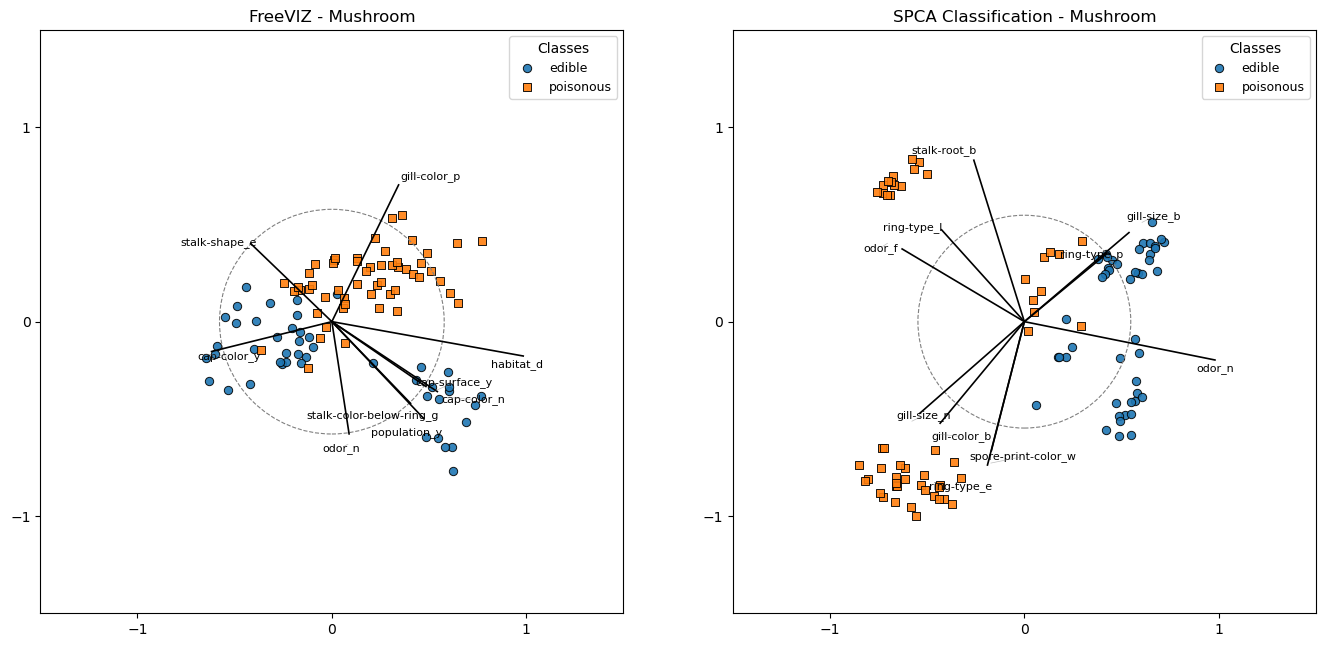

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))

plot_projection(
    points=P_mush_np, vectors=A_mush_np, feature_names=feature_names_mush,
    class_codes=C_mush_np, class_names=class_names_mush,
    title='FreeVIZ - Mushroom', ax=ax1, text_scale=1.08, top_n_loadings=10, normalize_points=True
)

plot_projection(
    points=Z_mush_np, vectors=L_mush_np, feature_names=feature_names_mush,
    class_codes=C_mush_np_spca, class_names=class_names_mush,
    title='SPCA Classification - Mushroom', ax=ax2, text_scale=1.1, top_n_loadings=10
)

plt.tight_layout()
plt.show()

# The BREAST CANCER dataset

#### Data preparation

In [16]:
E_bc, C_bc, names_bc, feature_names_bc, class_names_bc = load_breast_cancer_data(device)
E_bc = scale_features(E_bc)

In [17]:
# Select optimal lambda for SPCA on Breast Cancer data
E_bc_f64 = E_bc.to(torch.float64)
best_lam_bc = select_lambda(SPCA_Classification, E_bc_f64, C_bc,
                             num_classes=len(class_names_bc), steps=500)


Step 0: loss = 0.6668, classifier loss = 0.6654
Step 10: loss = 0.5212, classifier loss = 0.5195
Step 20: loss = 0.4388, classifier loss = 0.4370
Step 30: loss = 0.3805, classifier loss = 0.3786
Step 40: loss = 0.3374, classifier loss = 0.3355
Step 50: loss = 0.3044, classifier loss = 0.3024
Step 60: loss = 0.2784, classifier loss = 0.2764
Step 70: loss = 0.2576, classifier loss = 0.2555
Step 80: loss = 0.2406, classifier loss = 0.2384
Step 90: loss = 0.2264, classifier loss = 0.2242
Step 100: loss = 0.2146, classifier loss = 0.2123
Step 110: loss = 0.2086, classifier loss = 0.2063
Step 120: loss = 0.2074, classifier loss = 0.2051
Step 130: loss = 0.2063, classifier loss = 0.2039
Step 140: loss = 0.2051, classifier loss = 0.2028
Step 150: loss = 0.2040, classifier loss = 0.2016
Step 160: loss = 0.2029, classifier loss = 0.2005
Step 170: loss = 0.2018, classifier loss = 0.1994
Step 180: loss = 0.2007, classifier loss = 0.1983
Step 190: loss = 0.1997, classifier loss = 0.1973
Step 200: l

#### Train FreeVIZ

In [18]:
freeviz_bc = Freeviz(E_bc.shape[1]).to(device)
freeviz_bc.train(E_bc, C_bc)

P_bc = freeviz_bc(E_bc)
A_bc = freeviz_bc.A
P_bc_np = P_bc.detach().cpu().numpy()
C_bc_np = C_bc.detach().cpu().numpy()
A_bc_np = A_bc.detach().cpu().numpy()

step: 1 loss: 716257.625
step: 2 loss: 1011298.5625
step: 3 loss: 869791.8125
step: 4 loss: 802809.5
step: 5 loss: 806706.25
step: 6 loss: 786447.0
step: 7 loss: 750849.4375
step: 8 loss: 656695.0625
step: 9 loss: 697658.25
step: 10 loss: 658344.75
step: 11 loss: 681721.625


#### Train SPCA Classification

In [19]:
model_bc = SPCA_Classification(input_dim=E_bc.shape[1], latent_dim=2, num_classes=len(class_names_bc), lr=0.05).to(device)
E_bc_centered = E_bc - E_bc.mean(dim=0)
model_bc.train(E_bc_centered, C_bc, lam=best_lam_bc, steps=1000, classifier_epochs=50)

L_bc = model_bc.L.detach().clone()
L_bc = L_bc - L_bc.mean(dim=0, keepdim=True)
loading_norms_bc = torch.norm(L_bc, dim=1)
L_bc = L_bc / loading_norms_bc.max()

Z_bc = E_bc_centered @ L_bc
z_max_bc = torch.abs(Z_bc).max()
Z_bc = Z_bc / z_max_bc

Z_bc_np = Z_bc.cpu().numpy()
C_bc_np_spca = C_bc.cpu().numpy()
L_bc_np = L_bc.cpu().numpy()

Step 0: loss = 1.9631, classifier loss = 0.6672
Step 10: loss = 1.8155, classifier loss = 0.5194
Step 20: loss = 1.7326, classifier loss = 0.4364
Step 30: loss = 1.6745, classifier loss = 0.3783
Step 40: loss = 1.6317, classifier loss = 0.3354
Step 50: loss = 1.5991, classifier loss = 0.3027
Step 60: loss = 1.5735, classifier loss = 0.2772
Step 70: loss = 1.5531, classifier loss = 0.2567
Step 80: loss = 1.5365, classifier loss = 0.2401
Step 90: loss = 1.5230, classifier loss = 0.2266
Step 100: loss = 1.5118, classifier loss = 0.2154
Step 110: loss = 1.5097, classifier loss = 0.2133
Step 120: loss = 1.5086, classifier loss = 0.2121
Step 130: loss = 1.5074, classifier loss = 0.2110
Step 140: loss = 1.5063, classifier loss = 0.2099
Step 150: loss = 1.5052, classifier loss = 0.2088
Step 160: loss = 1.5042, classifier loss = 0.2077
Step 170: loss = 1.5031, classifier loss = 0.2067
Step 180: loss = 1.5021, classifier loss = 0.2057
Step 190: loss = 1.5011, classifier loss = 0.2047
Step 200: l

### Side-by-side comparison

/usr/lib/python3/dist-packages/matplotlib/transforms.py:627: RuntimeWarning: invalid value encountered in scalar subtract
  deltaw = (sw * width - width) / 2.0
/usr/lib/python3/dist-packages/matplotlib/transforms.py:628: RuntimeWarning: invalid value encountered in scalar subtract
  deltah = (sh * height - height) / 2.0


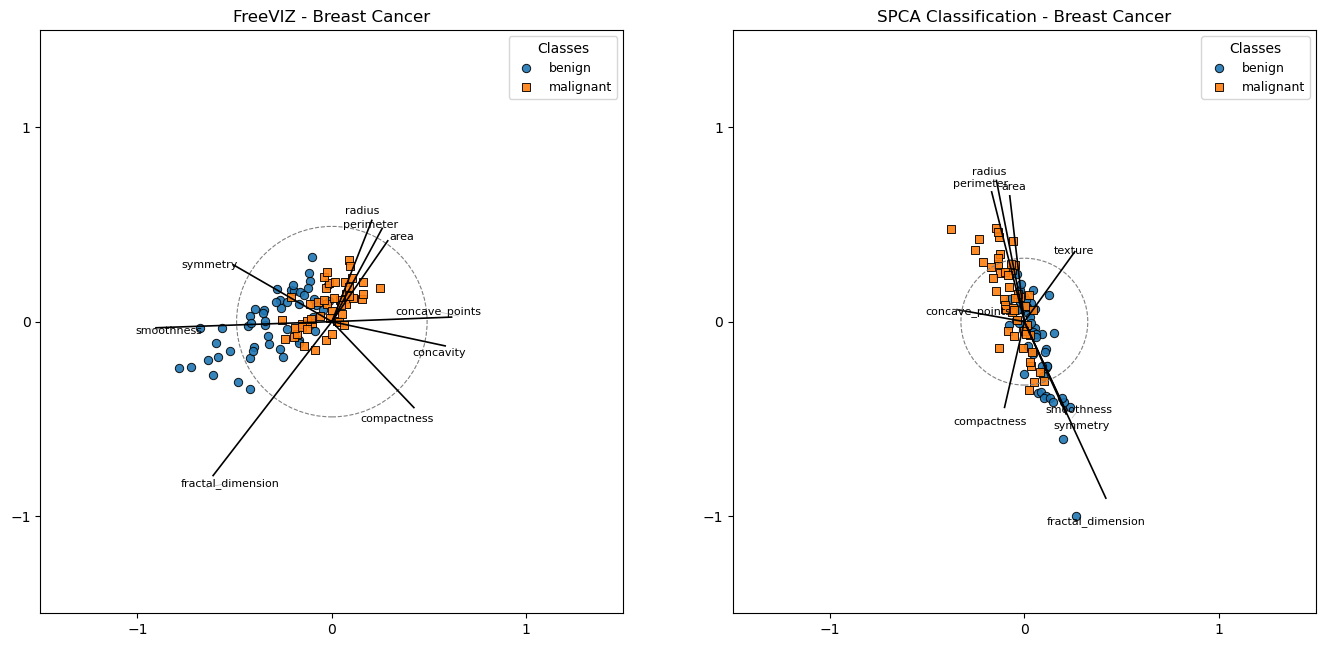

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))

plot_projection(
    points=P_bc_np, vectors=A_bc_np, feature_names=feature_names_bc,
    class_codes=C_bc_np, class_names=class_names_bc,
    title='FreeVIZ - Breast Cancer', ax=ax1, text_scale=1.08, top_n_loadings=10, normalize_points=True
)

plot_projection(
    points=Z_bc_np, vectors=L_bc_np, feature_names=feature_names_bc,
    class_codes=C_bc_np_spca, class_names=class_names_bc,
    title='SPCA Classification - Breast Cancer', ax=ax2, text_scale=1.1, top_n_loadings=10
)

plt.tight_layout()
plt.show()